<a href="https://colab.research.google.com/github/kvssri/online-tihiitg/blob/main/classical_enhancement_and_edge_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Underwater-Image-Data-set-main.zip to Underwater-Image-Data-set-main.zip


In [3]:
import zipfile
import os
import pandas as pd

zip_file = list(uploaded.keys())[0]

extract_path = "/content/underwater_data"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP extracted successfully!")

for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

ZIP extracted successfully!
/content/underwater_data/Underwater-Image-Data-set-main/README.md
/content/underwater_data/Underwater-Image-Data-set-main/epoch_0110.7z
/content/underwater_data/Underwater-Image-Data-set-main/epoch_0135.7z
/content/underwater_data/Underwater-Image-Data-set-main/epoch_0120.7z
/content/underwater_data/Underwater-Image-Data-set-main/epoch_0115.7z
/content/underwater_data/Underwater-Image-Data-set-main/training_log 1.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 5.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 3.csv
/content/underwater_data/Underwater-Image-Data-set-main/epoch_0096.7z
/content/underwater_data/Underwater-Image-Data-set-main/training_log 6.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 8.csv
/content/underwater_data/Underwater-Image-Data-set-main/epoch_0100.7z
/content/underwater_data/Underwater-Image-Data-set-main/epoch_00100.7z
/content/underwater_data/Underwater-Imag

In [5]:
import zipfile
import os
import glob
import pandas as pd

# Find the uploaded ZIP file
zip_files = glob.glob("/content/*.zip")

print("ZIP files found:", zip_files)

# Use the first ZIP file
zip_file = zip_files[0]

# Extract
extract_path = "/content/underwater_data"

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("\nZIP extracted successfully!")

# Find all CSV files
csv_files = glob.glob(
    extract_path + "/**/*.csv",
    recursive=True
)

print("\nCSV files found:")
for f in csv_files:
    print(f)

# Read and display information
print("\n===== CSV INFORMATION =====")

for f in csv_files:
    print("\nFILE:", os.path.basename(f))

    temp = pd.read_csv(f)

    print("Shape:", temp.shape)
    print("Columns:", temp.columns.tolist())
    print(temp.head(3))

ZIP files found: ['/content/Underwater-Image-Data-set-main.zip']

ZIP extracted successfully!

CSV files found:
/content/underwater_data/Underwater-Image-Data-set-main/training_log 1.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 5.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 3.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 6.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 8.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 4.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 7.csv
/content/underwater_data/Underwater-Image-Data-set-main/training_log 2.csv

===== CSV INFORMATION =====

FILE: training_log 1.csv
Shape: (3900, 5)
Columns: ['epoch', 'step', 'gen_total', 'disc_loss', 'time_s']
   epoch  step  gen_total  disc_loss     time_s
0      1     1  49.983898   0.836880  18.457536
1      1     2  43.539597   1.387914  21.958980
2      1 

In [6]:
import pandas as pd
import os

all_logs = []

for f in csv_files:
    temp = pd.read_csv(f)
    temp["source_file"] = os.path.basename(f)
    all_logs.append(temp)

df = pd.concat(all_logs, ignore_index=True)

print("Combined dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

Combined dataset shape: (24915, 6)

Columns:
['epoch', 'step', 'gen_total', 'disc_loss', 'time_s', 'source_file']


,epoch,step,gen_total,disc_loss,time_s,source_file
0,1,1,49.983898,0.836880,18.457536,training_log 1.csv
1,1,2,43.539597,1.387914,21.958980,training_log 1.csv
2,1,3,42.768696,1.347370,25.453557,training_log 1.csv
3,1,4,39.263531,0.730509,28.940288,training_log 1.csv
4,1,5,41.176651,0.746207,32.288328,training_log 1.csv


In [7]:
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24915 entries, 0 to 24914
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   epoch        24915 non-null  int64  
 1   step         24915 non-null  int64  
 2   gen_total    24915 non-null  float64
 3   disc_loss    24915 non-null  float64
 4   time_s       24915 non-null  float64
 5   source_file  24915 non-null  object 
dtypes: float64(3), int64(2), object(1)
memory usage: 1.1+ MB
None

Missing values:
epoch          0
step           0
gen_total      0
disc_loss      0
time_s         0
source_file    0
dtype: int64


In [8]:
display(df.describe())

,epoch,step,gen_total,disc_loss,time_s
count,24915.000000,24915.000000,24915.000000,24915.000000,24915.000000
mean,52.333935,1835.712462,13.347087,0.551729,96.163017
std,29.743196,1129.729162,7.621047,0.292557,213.210639
min,1.000000,1.000000,3.235735,0.020976,4.876095
25%,27.000000,850.000000,7.840670,0.418167,45.790789
50%,53.000000,1776.000000,11.780836,0.548061,79.022856
75%,77.000000,2814.000000,16.629889,0.655409,112.391965
max,136.000000,3900.000000,90.369987,11.538145,7865.182561


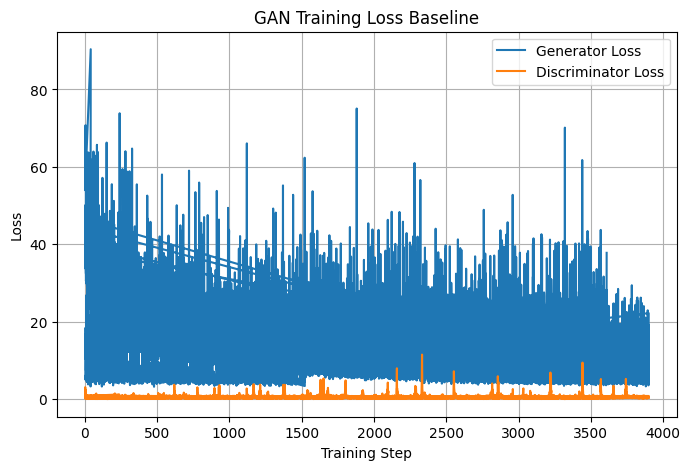

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(df["step"], df["gen_total"], label="Generator Loss")
plt.plot(df["step"], df["disc_loss"], label="Discriminator Loss")

plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("GAN Training Loss Baseline")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Remove missing values
baseline_df = df[["step", "gen_total"]].dropna()

X = baseline_df[["step"]]
y = baseline_df["gen_total"]

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Linear Regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print("Baseline model trained successfully!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Baseline model trained successfully!
Training samples: 19932
Testing samples: 4983


In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# MAPE
non_zero = y_test != 0

mape = np.mean(
    np.abs((y_test[non_zero] - y_pred[non_zero]) /
           y_test[non_zero])
) * 100

r2 = r2_score(y_test, y_pred)

print("===== BASELINE METRICS =====")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

===== BASELINE METRICS =====
MAE  : 5.0323
RMSE : 6.9934
MAPE : 48.33%
R²   : 0.1723


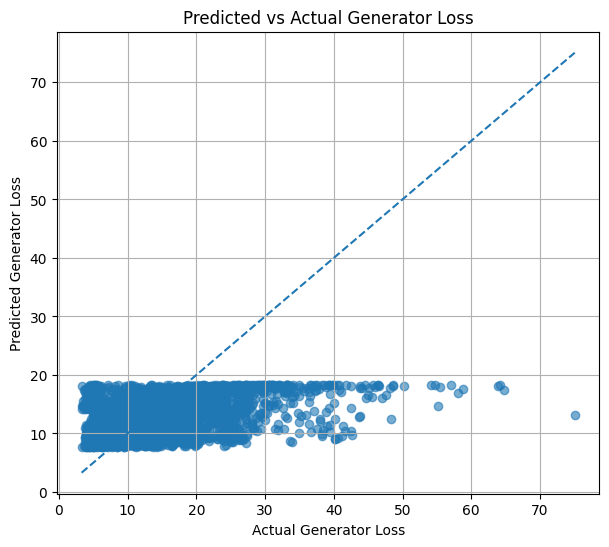

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Generator Loss")
plt.ylabel("Predicted Generator Loss")
plt.title("Predicted vs Actual Generator Loss")
plt.grid(True)
plt.show()

In [13]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "R2"],
    "Value": [mae, rmse, mape, r2]
})

display(metrics)

metrics.to_csv(
    "/content/day13_baseline_metrics.csv",
    index=False
)

print("Metrics file saved.")

,Metric,Value
0,MAE,5.032328
1,RMSE,6.993448
2,MAPE,48.328132
3,R2,0.172339


Metrics file saved.


In [14]:
prediction_results = pd.DataFrame({
    "Actual_Generator_Loss": y_test.values,
    "Predicted_Generator_Loss": y_pred
})

display(prediction_results.head(10))

prediction_results.to_csv(
    "/content/day13_predictions.csv",
    index=False
)

print("Prediction results saved successfully.")

,Actual_Generator_Loss,Predicted_Generator_Loss
0,11.075317,7.885162
1,5.367224,10.037865
2,21.723322,15.588998
3,7.788158,12.974611
4,10.752353,13.381658
5,5.027991,16.668081
6,12.527283,10.882009
7,18.087852,12.665911
8,13.152472,12.551173
9,11.896037,11.764399


Prediction results saved successfully.


In [15]:
from google.colab import files

files.download("/content/day13_baseline_metrics.csv")
files.download("/content/day13_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>